In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

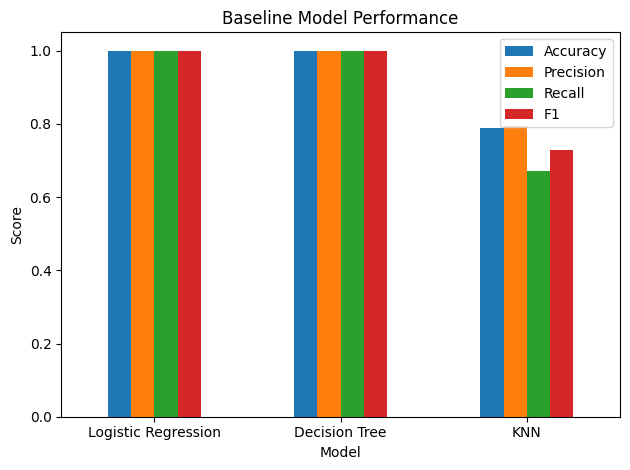

In [9]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# Target
df['mental_risk'] = (df['Work_Stress_Level'] > df['Work_Stress_Level'].median()).astype(int)

# Preprocessing
df = pd.get_dummies(df, drop_first=True)
df = df.fillna(df.mean())

X = df.drop('mental_risk', axis=1)
y = df['mental_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# =========================
# 3. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

# =========================
# 4. TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
results_df.to_csv("RQ1_table.csv", index=False)

# =========================
# 5. FIGURE
# =========================
results_df.set_index("Model").plot(kind='bar')
plt.title("Baseline Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("RQ1_figure.pdf")
plt.show()